# Lab 1 — Robotics Framework: Getting Started

## Block 1 — Environment Verification

Before developing a robotic system, we first verify that our Python
robotics development environment is working correctly.

### 1. Check the Python Environment

We begin by checking which Python interpreter is being used.

In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.15 (main, Aug  5 2026, 12:25:43) [Clang 21.0.0 (clang-2100.1.1.101)]

Python executable:
/Users/nippunkumaaraa/Work/BITS-WILP/Robotics/lab/.venv/bin/python


Expected: the executable should point to your project's .venv.

### 2. Check the Core Scientific Libraries

Robotics algorithms rely heavily on numerical computation and
visualization. We will use NumPy, SciPy, and Matplotlib throughout
this course.

In [2]:
import numpy as np
import scipy
import matplotlib

print("NumPy      :", np.__version__)
print("SciPy      :", scipy.__version__)
print("Matplotlib :", matplotlib.__version__)

NumPy      : 2.3.5
SciPy      : 1.17.1
Matplotlib : 3.11.0


### 3. Test Numerical Computation

In [3]:
x = np.array([1, 2, 3, 4, 5])
y = x ** 2

print("x =", x)
print("x² =", y)

x = [1 2 3 4 5]
x² = [ 1  4  9 16 25]


### 4. Test Visualization

A robotics development environment must also be able to visualize
robot states, trajectories, sensor measurements, and simulation
results.

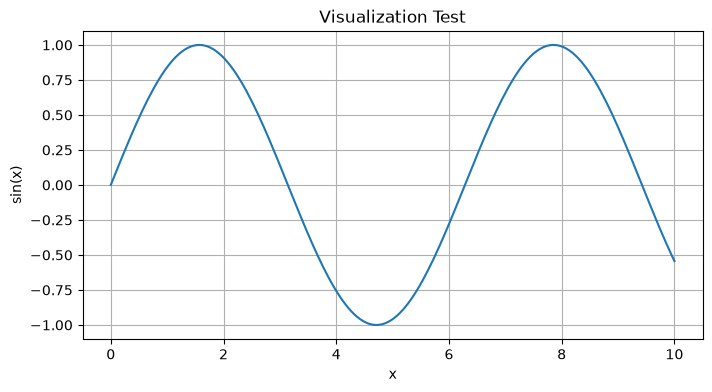

In [4]:
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Visualization Test")
plt.grid(True)
plt.show()

### Environment Checkpoint

If all the cells above execute successfully, our basic robotics
programming environment is ready.

**Python ✓**

**NumPy ✓**

**SciPy ✓**

**Matplotlib ✓**

**Visualization ✓**

## Block 2 — Robotics Framework

Robotics software is built using reusable libraries and algorithms.

In this course, we will use **PythonRobotics** as a reference robotics
framework and algorithm library.

It provides implementations and demonstrations of many classical
robotics algorithms that we will encounter throughout the course.

### 2.1 Explore the Robotics Framework

PythonRobotics is organized according to different robotics capabilities,
such as:

- Mapping
- SLAM
- Path Tracking
- Path Planning
- Localization
- Other robotics algorithms

We will use only the components relevant to each laboratory.

In [5]:
import numpy as np
import scipy
import matplotlib
import cvxpy

print("PythonRobotics environment check")
print("--------------------------------")
print("NumPy      :", np.__version__)
print("SciPy      :", scipy.__version__)
print("Matplotlib :", matplotlib.__version__)
print("CVXPY      :", cvxpy.__version__)

print("\nPythonRobotics dependencies: READY")

PythonRobotics environment check
--------------------------------
NumPy      : 2.3.5
SciPy      : 1.17.1
Matplotlib : 3.11.0
CVXPY      : 1.8.1

PythonRobotics dependencies: READY


### 2.2 Where PythonRobotics Fits in Our Course

PythonRobotics will serve as a supporting robotics library.

Our laboratory work will progressively build **one warehouse AMR**,
while selected PythonRobotics implementations will be used to
understand and experiment with robotics algorithms.

We will not treat the repository itself as our robot.

**PythonRobotics → Algorithms**

**Our Lab Framework → Warehouse AMR**

### Why are we using a robotics framework?

Instead of implementing every robotics algorithm from scratch, a
framework allows us to:

- reuse established implementations,
- visualize algorithms,
- experiment with parameters, and
- focus on understanding the robotics problem.

Throughout the laboratories, we will progressively add capabilities
to the same warehouse AMR.

## Block 3 — Our Warehouse AMR

Throughout the laboratories, we will progressively build one
differential-drive autonomous warehouse mobile robot.

Our reference robot has:

- Two independently driven wheels
- Wheel encoders
- IMU
- 2D LiDAR
- RGB camera
- Onboard computer

For now, we represent only the robot's **pose**:

- x — position along the x-axis
- y — position along the y-axis
- θ — orientation

### 3.1 Representing the Robot Pose

A robot pose describes:

**Where is the robot?**

and

**Which direction is it facing?**

We represent the pose as:

    [x, y, θ]

For this first implementation, the pose is simply stored as data.
We will introduce robot motion and uncertainty in later laboratories.

In [6]:
import numpy as np

# Initial pose of our warehouse AMR
robot_pose = np.array([2.0, 3.0, 0.0])

print("Robot pose [x, y, θ]:")
print(robot_pose)

Robot pose [x, y, θ]:
[2. 3. 0.]


### 3.2 Create a Robot Object

Instead of storing the robot pose as a standalone array, we will create
a simple robot object.

This will allow us to extend the robot later with:

- motion,
- sensors,
- environment interaction, and
- other capabilities.

In [7]:
class DifferentialDriveRobot:
    def __init__(self, x=0.0, y=0.0, theta=0.0):
        self.x = x
        self.y = y
        self.theta = theta

    def pose(self):
        return np.array([self.x, self.y, self.theta])

In [8]:
robot = DifferentialDriveRobot(
    x=2.0,
    y=3.0,
    theta=0.0
)

print("Robot pose [x, y, θ]:")
print(robot.pose())

Robot pose [x, y, θ]:
[2. 3. 0.]


### 3.3 Inspect the Robot State

Our robot currently stores three pieces of information:

- x-position
- y-position
- orientation

At this stage, the robot **cannot move**.

This is intentional.

In later laboratories, we will add models that determine how the
robot's pose changes when it receives motion commands.

### Exercise 3.1 — Change the Robot Pose

Create a robot with:

- x = 5.0 m
- y = 2.0 m
- θ = π/2 rad

Print its pose.

What direction is the robot facing when θ = π/2?

In [9]:
robot = DifferentialDriveRobot(
    x=5.0,
    y=2.0,
    theta=np.pi / 2
)

print(robot.pose())

[5.         2.         1.57079633]


## Block 4 — Visualizing Our Warehouse AMR

A numerical pose is useful for computation, but robotics also requires
visualization.

We will now represent our warehouse AMR in a 2D coordinate system.

The visualization will show:

- Robot position
- Robot orientation
- Robot body
- Direction of travel

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_robot(robot, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    x = robot.x
    y = robot.y
    theta = robot.theta

    # Robot dimensions
    length = 1.0
    width = 0.6

    # Robot body corners defined relative to its centre
    corners = np.array([
        [-length / 2, -width / 2],
        [ length / 2, -width / 2],
        [ length / 2,  width / 2],
        [-length / 2,  width / 2],
        [-length / 2, -width / 2]
    ])

    # Rotation matrix
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    # Rotate and translate the robot body
    rotated_corners = corners @ R.T
    rotated_corners += np.array([x, y])

    # Draw robot body
    ax.plot(
        rotated_corners[:, 0],
        rotated_corners[:, 1],
        linewidth=2
    )

    # Draw heading direction
    heading_length = 0.8

    ax.arrow(
        x,
        y,
        heading_length * np.cos(theta),
        heading_length * np.sin(theta),
        head_width=0.15,
        length_includes_head=True
    )

    # Robot centre
    ax.plot(x, y, "o")

    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(True)

    return ax

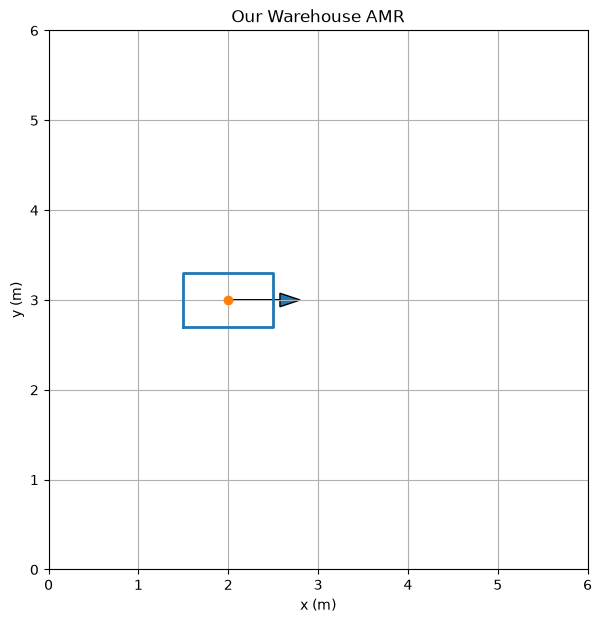

In [14]:
robot = DifferentialDriveRobot(
    x=2.0,
    y=3.0,
    theta=0.0
)

fig, ax = plt.subplots(figsize=(7, 7))
plot_robot(robot, ax)

ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_title("Our Warehouse AMR")

plt.show()

### Exercise 4.1 — Change the Robot Orientation

Change the robot orientation to:

θ = π/2

Run the visualization again.

Observe how the heading direction changes.

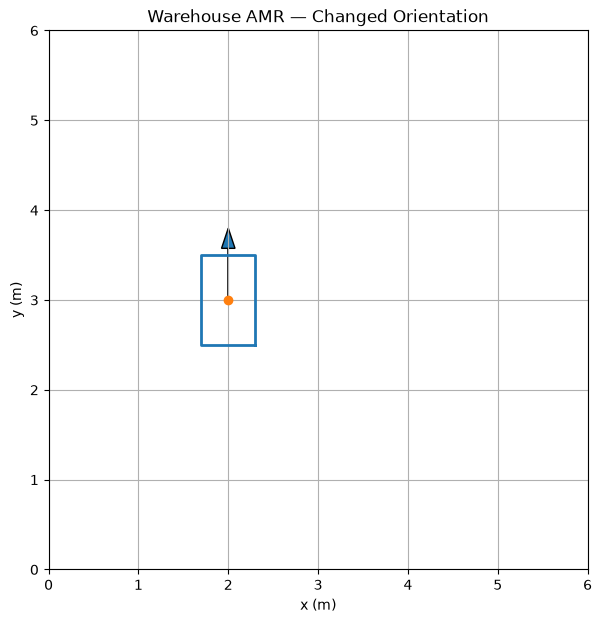

In [15]:
robot = DifferentialDriveRobot(
    x=2.0,
    y=3.0,
    theta=np.pi / 2
)

fig, ax = plt.subplots(figsize=(7, 7))
plot_robot(robot, ax)

ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_title("Warehouse AMR — Changed Orientation")

plt.show()

### What did you observe?

The robot's position did not change.

Only its orientation changed.

This simple representation will become more meaningful as we introduce
robot motion, sensors, uncertainty, and eventually localization.

## Block 5 — Lab 1 Checkpoint

Modify the robot configuration below and observe the result.

### Task

Create a warehouse AMR with:

- x = 4.0 m
- y = 2.0 m
- θ = π/4 rad

Then visualize the robot.

### Think about:

1. Where is the robot located?
2. Which direction is it facing?
3. What changes when you modify x, y, or θ?